## Imports

In [ ]:
import numpy as np
import pandas as pd
import tensorflow as tf

## Bitcoin Price Prediction

In [5]:
# Create pandas dataframe
data = pd.read_csv('BTC-USD.csv')

In [6]:
# Plot data.head()
data.head()

,Date,Open,High,Low,Close,Adj Close,Volume
0,2014-09-17,465.864014,468.174011,452.421997,457.334015,457.334015,21056800.0
1,2014-09-18,456.859985,456.859985,413.104004,424.440002,424.440002,34483200.0
2,2014-09-19,424.102997,427.834991,384.532013,394.795990,394.795990,37919700.0
3,2014-09-20,394.673004,423.295990,389.882996,408.903992,408.903992,36863600.0
4,2014-09-21,408.084991,412.425995,393.181000,398.821014,398.821014,26580100.0


Plot the bitcoin price every day after September 15, 2014. Day "0" indicates September 15, 2014.

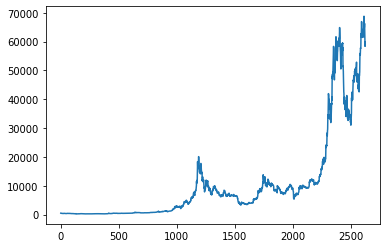

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns # Used for plotting

g = sns.lineplot(x = np.linspace(1,2622,2622), y = data['High'].values.reshape(-1))

Plot bitcoin vs. days

[Text(0, 0, '2014-09-17'),
 Text(0, 0, '2015-04-05'),
 Text(0, 0, '2015-10-22'),
 Text(0, 0, '2016-05-09'),
 Text(0, 0, '2016-11-25'),
 Text(0, 0, '2017-06-13'),
 Text(0, 0, '2017-12-30'),
 Text(0, 0, '2018-07-18'),
 Text(0, 0, '2019-02-03'),
 Text(0, 0, '2019-08-22'),
 Text(0, 0, '2020-03-09'),
 Text(0, 0, '2020-09-25'),
 Text(0, 0, '2021-04-13')]

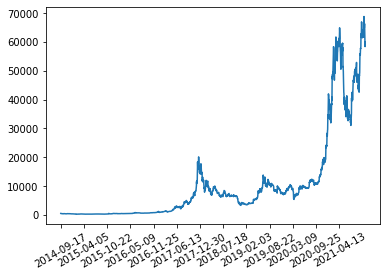

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

g = sns.lineplot(x = np.linspace(1,2622,2622), y = data['High'].values.reshape(-1))
g.set(xticks=np.arange(0,2500,200))
g.set_xticklabels(rotation=30, labels = data['Date'][0::200])

### Data Preprocessing

In [ ]:
# Create a dataframe that only contains High Column.
data_high = data[['High']].values
data_high = data_high.astype(np.float32)
data_high

array([  468.174,   456.86 ,   427.835, ..., 60948.5  , 58351.113,
       59859.88 ], dtype=float32)

In [ ]:
# Remove enteries from the data with missing values. 
data_high = data_high[~np.isnan(data_high)]

In [11]:
from sklearn.preprocessing import MinMaxScaler

#Normalizing the data set
scaler = MinMaxScaler(feature_range = (0,1))
data_normalized = scaler.fit_transform(data_high.reshape(-1,1))
data_normalized

#Removing extra dimension
data_normalized = data_normalized.reshape(-1,)

In [12]:
def create_dataset(dataset, time_steps=1):
    """
    Generate a dataset where the time series X[n] contains the readings for the 'time_step' previous days 
    and y contains the price for today.
    args:
    dataset: numpy array, the data
    time_steps: the number of previous days to feed to RNN

    returns:
    tuple: a dataset with x[i] containing 'time_step' number of previous prices, target price for x[i]
    """
    dataX, dataY = [],[]
    for i in range(len(dataset)-time_steps-1):
        a = dataset[i:(i+time_steps)]
        dataX.append(a)
        dataY.append(dataset[i + time_steps])
    return np.array(dataX), np.array(dataY)

In [ ]:
# Choose the number of time steps that the model "looks back"
time_steps = 4

# Create dataset based on the number of days the model could look back
X, y = create_dataset(data_normalized, time_steps)

print(X.shape, y.shape)

### Data Partitioning

In [15]:
#Splitting X data into train and test sets
train_size = int(len(X) * 0.80)
test_size = len(X) - train_size
X_train, X_test = X[0: train_size, :], X[train_size: len(X), :]
print(len(X_train), len(X_test))

#Splitting y data into train and test sets
y_train_size = int(len(y) * 0.80)
y_test_size = len(y) - train_size
y_train = y[0: y_train_size] 
y_test = y[y_train_size: len(y)]
print(len(y_train), len(y_test))

2090 523
2090 523


In [ ]:
# Reshape input to be [samples, time steps, features].
X_train = np.reshape(X_train, (X_train.shape[0], 1, X_train.shape[1]))
X_test = np.reshape(X_test, (X_test.shape[0], 1, X_test.shape[1]))

X_train.shape

(2090, 1, 4)

In [17]:
X_test.shape

(523, 1, 4)

### LSTM Model

In [22]:
from tensorflow.keras.layers import Bidirectional
from tensorflow.keras.callbacks import EarlyStopping

# Build your model
stoppage = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True)
model = Sequential()
model.add(Bidirectional(LSTM(100, input_shape=(1, time_steps))))
model.add(Dense(20, activation = 'relu'))
model.add(Dense(1))

loss = 'mean_squared_error'
opt = 'adam'
metrics = 'mean_squared_error'

#Compile model
model.compile(loss = loss, 
              optimizer = opt,
              metrics = metrics)

In [23]:
batchsize = 20
epochs = 50

# Fit model - Use 20% validation split
history = model.fit(X_train, 
                 y_train,
                 validation_split = 0.2,
                 epochs = epochs, 
                 batch_size = batchsize,
                 verbose = 2,
                 shuffle = False,
                 callbacks = [stoppage]
                 )

Epoch 1/50
84/84 - 4s - loss: 7.4272e-04 - mean_squared_error: 7.4272e-04 - val_loss: 0.0027 - val_mean_squared_error: 0.0027 - 4s/epoch - 53ms/step
Epoch 2/50
84/84 - 0s - loss: 0.0022 - mean_squared_error: 0.0022 - val_loss: 1.8595e-04 - val_mean_squared_error: 1.8595e-04 - 445ms/epoch - 5ms/step
Epoch 3/50
84/84 - 0s - loss: 0.0018 - mean_squared_error: 0.0018 - val_loss: 1.5216e-04 - val_mean_squared_error: 1.5216e-04 - 427ms/epoch - 5ms/step
Epoch 4/50
84/84 - 0s - loss: 5.3294e-04 - mean_squared_error: 5.3294e-04 - val_loss: 7.8940e-05 - val_mean_squared_error: 7.8940e-05 - 409ms/epoch - 5ms/step
Epoch 5/50
84/84 - 0s - loss: 3.9153e-04 - mean_squared_error: 3.9153e-04 - val_loss: 6.8557e-05 - val_mean_squared_error: 6.8557e-05 - 448ms/epoch - 5ms/step
Epoch 6/50
84/84 - 0s - loss: 1.3901e-04 - mean_squared_error: 1.3901e-04 - val_loss: 1.0051e-04 - val_mean_squared_error: 1.0051e-04 - 402ms/epoch - 5ms/step
Epoch 7/50
84/84 - 0s - loss: 8.7407e-05 - mean_squared_error: 8.7407e-0

Training lowest loss: 8.740703196963295e-05
Validation lowest loss: 6.855680112494156e-05


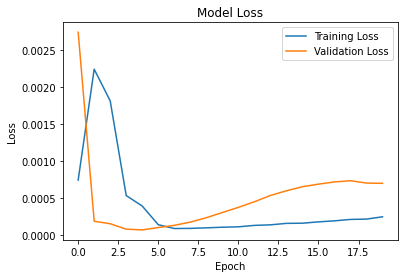

In [24]:
#Code from Rafael's section used to plot the Vladiation loss
def plot_losses(hist):
    print('Training lowest loss:', min(hist.history['loss']))
    print('Validation lowest loss:', min(hist.history['val_loss']))
    plt.plot(hist.history['loss'])
    plt.plot(hist.history['val_loss'])
    plt.title('Model Loss')
    plt.ylabel('Loss')
    plt.xlabel('Epoch')
    plt.legend(['Training Loss', 'Validation Loss'])
    plt.show()

# Plot the model loss
plot_losses(history)

In [25]:
#Model Summary
model.summary()

Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 bidirectional (Bidirectiona  (None, 200)              84000     
 l)                                                              
                                                                 
 dense_1 (Dense)             (None, 20)                4020      
                                                                 
 dense_2 (Dense)             (None, 1)                 21        
                                                                 
Total params: 88,041
Trainable params: 88,041
Non-trainable params: 0
_________________________________________________________________


### Looking at Predictions

In [26]:
from sklearn.metrics import mean_squared_error, r2_score

#Predictions
trainPredict = model.predict(X_train)
testPredict = model.predict(X_test)

#Reshape y
y_train = y_train.reshape(-1,1)
y_test = y_test.reshape(-1,1)

#Inverting Predictions
trainPredict = scaler.inverse_transform(trainPredict.reshape((-1,1)))
trainY = scaler.inverse_transform(y_train)
testPredict = scaler.inverse_transform(testPredict.reshape((-1,1)))
testY = scaler.inverse_transform(y_test)
testPredict[:10]

#Calculating RMSE of predictions
trainScore = np.sqrt(mean_squared_error(trainY[0], trainPredict[0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = np.sqrt(mean_squared_error(testY[0], testPredict[0]))
print('Test Score: %.2f RMSE' % (testScore))
print('R2 score: ', r2_score(testY, testPredict))

17/17 [==============================] - 0s 2ms/step
Train Score: 877.49 RMSE
Test Score: 28.50 RMSE
R2 score:  0.9873659685914065


In [ ]:
trainPredict = trainPredict.reshape(-1,)

In [28]:
testPredict = testPredict.reshape(-1,)

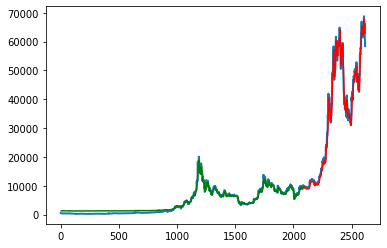

In [ ]:
# shift train predictions for plotting
trainPredictPlot = np.empty_like(data_normalized)
trainPredictPlot[:] = np.nan
trainPredictPlot[time_steps: len(trainPredict) + time_steps] = trainPredict

# shift test predictions for plotting
testPredictPlot = np.empty_like(data_normalized)
testPredictPlot[:] = np.nan
testPredictPlot[len(trainPredict) + time_steps: len(data_normalized) - 1] = testPredict

# plot baseline and predictions
plt.plot(scaler.inverse_transform(data_normalized.reshape(-1, 1)), linewidth=2)
plt.plot(trainPredictPlot, 'g')
plt.plot(testPredictPlot, 'r')
plt.show()

>I decided to look back a total of 4 days. I first started with an extreme number of look back days, 10, which had obscure results. I then tried the lowest number of look back days, 1, which did not provide the best result. I then tried even number of days starting at 2 and found that 4 days had the best result. I tried both 3 days and 5 days to confirm, it did confirm that 4 days was best for my model.
>
>For layers, I decided to add a total of 100 LSTM layers. I found that having either too low or too high number of LSTM layers resulted in poor results. There may be a more specific number instead of 100 that would improve the results of the model, but not by anything too significant which is why I stuck with 100 LSTM. I also didn't want too add too many dense layers so I added a simple 20 unit hidden layer and a single output layer. The model's prediction was nearly perfect.